In [20]:
# Generic packages
import numpy as np 
import matplotlib.pyplot as plt
from os import listdir
import pickle

# Style 
plt.style.use('seaborn-pastel')

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA, KernelPCA, NMF
from sklearn.model_selection import train_test_split
from sklearn.manifold import Isomap, TSNE, SpectralEmbedding, LocallyLinearEmbedding, MDS
from sklearn.neighbors import NearestNeighbors
from sklearn.mixture import GaussianMixture, BayesianGaussianMixture
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering, SpectralClustering, AffinityPropagation, MeanShift
from sklearn.cross_decomposition import CCA, PLSCanonical

from sklearn.preprocessing import StandardScaler

from tqdm.notebook import tqdm
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

C:\Users\dalbe\AppData\Local\Temp\ipykernel_16500\1409195534.py:8: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn-pastel')


### Functions

In [21]:
def build_dataset(path):
    """
    build_dataset(path)

        Import dataset from path, normalize data and separate in train and test datasets.

        -path (str) : Path to the dataset files. 
    """
    #496
    X = np.concatenate([np.fromfile(f"{path}{fileName}",dtype=np.uint16).reshape(-1,496) for fileName in listdir(path)])
    shape = np.shape(X)


    #X = (X - np.mean(X)) / (np.std(X))
    #X = StandardScaler().fit_transform(TES)
    X = (X - np.min(X)) / (np.max(X) - np.min(X))
    #X = TES

    X_train, X_test = train_test_split(X, test_size=0.001, random_state=0)

    print(f"Dataset contains :",
        f"\nSamples : {shape[0]}",
        f"\nLenght of samples : {shape[1]}",
        f"\nNumber of train samples : {len(X_train)}",
        f"\nNumber of test samples {len(X_test)}")
    
    return X_train , X_test

In [22]:
def reduction(X,function,plot=False, **param):
    """
    # reduction(X,function,plot=False,**param)

    Verifies if a function has been saved in the `DR preprocess` folder to avoid unnecessary computation. 

    -X (array-like, sparse matrix) : Inputs of the function that needs to be computed.
    -function (function) : Function that is executed.
    -param (**kwargs) : Multiple keyword arguments to define the parameters of `function`.
    
    """
    # File name
    file_name = f"{str(function.__name__)}_{str(param.items())}"
    print("File name : ", file_name)

    # Check for existing file
    try:
        result = np.load(f"DR preprocess\{file_name}.npy",allow_pickle=True)

    # Compute operation if file does not exist
    except:
        method = function(**param)
        result = method.fit_transform(X)
        np.save(f"DR preprocess\{file_name}",arr=result)
    
    # Plot results
    if plot:
        plt.scatter(result[:, 0], result[:, 1],alpha=0.005)
        plt.xlabel('First principal component')
        plt.ylabel('Second principal component')

    #plt.hist2d(result[:, 0], result[:, 1],bins=300)

    return result

In [23]:
def clustering(X, function, label_return = False,**param):
    """
    # clustering(X,function,**param)

        Run and plot a clustering technique defined with the function parameter.
        The process is based on `sklearn` structure.

    -X (array-like, sparse matrix) : Inputs of the function that needs to be computed.
    -function (function) : Function that is executed.
    -param (**kwargs) : Multiple keyword arguments to define the parameters of `function`.
    """

    labels = function(**param).fit_predict(X)

    plt.scatter(X[:, 0], X[:, 1], c=labels, s=10, cmap='Pastel2', alpha=0.05)
    plt.xlabel('First principal component')
    plt.ylabel('Second principal component')

    if label_return:
        return label_return


### Plot TES

Dataset contains : 
Samples : 52224 
Lenght of samples : 496 
Number of train samples : 52171 
Number of test samples 53


Text(0.5, 0, 'Time (a.u.)')

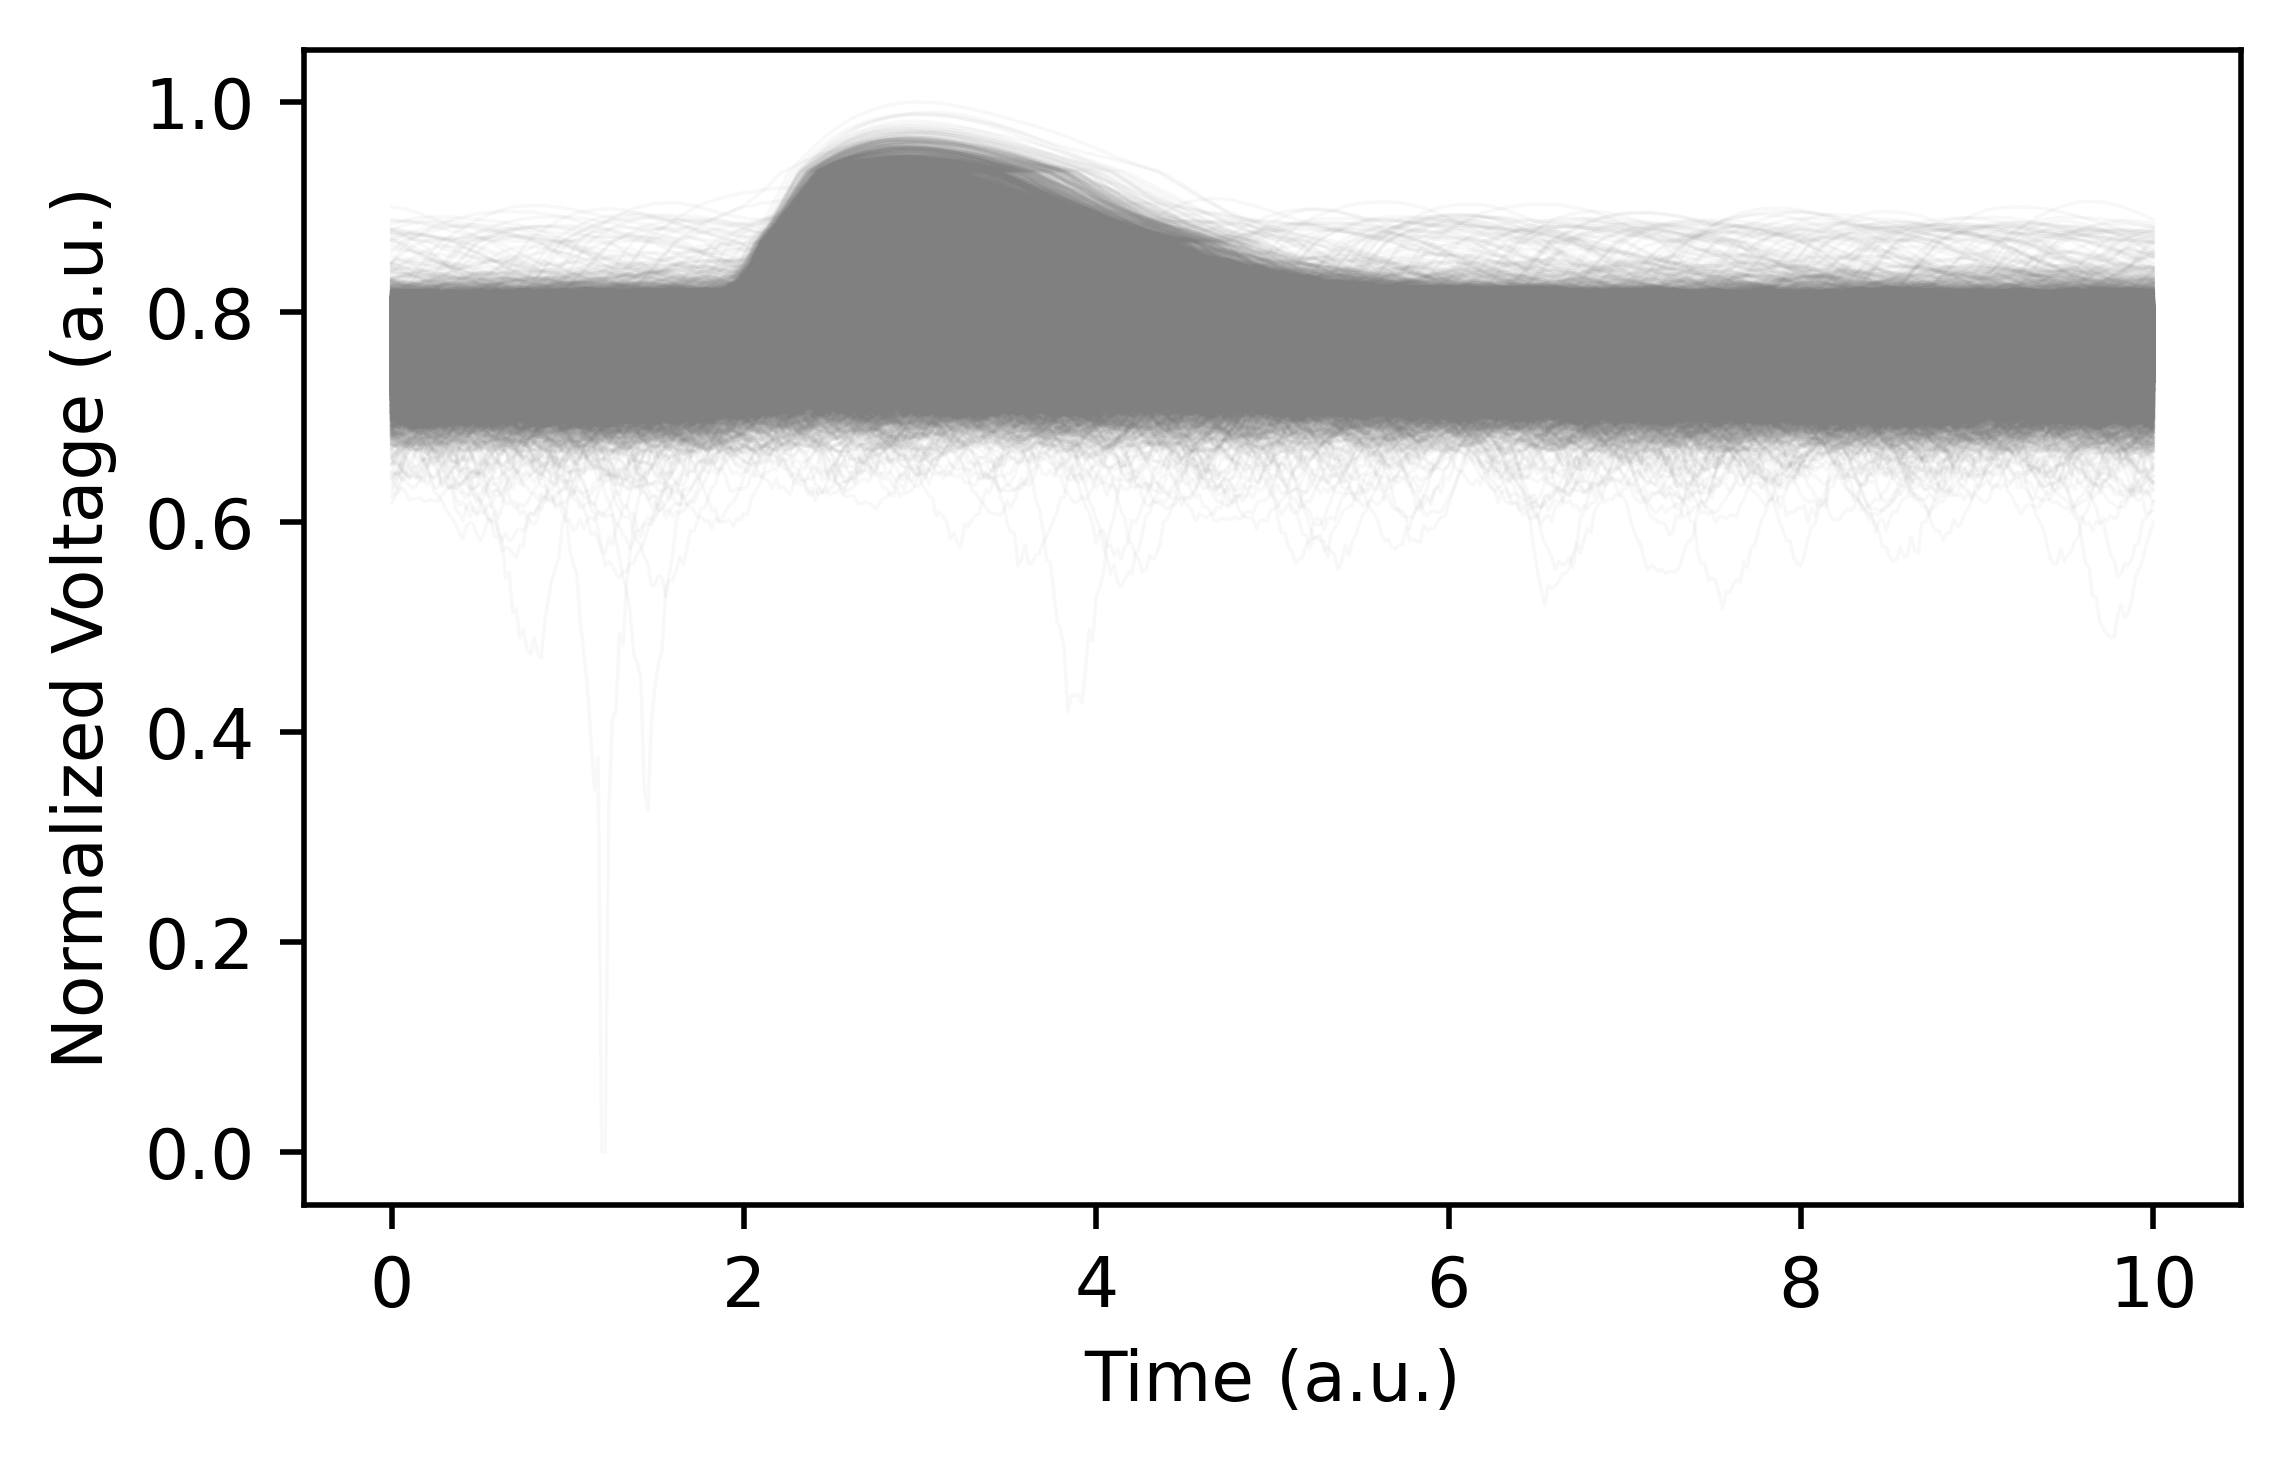

In [24]:
X, X_test = build_dataset("Datasets/Oxford/")
time = np.linspace(0,10,len(X_test[0]))

X = (X - np.min(X)) / (np.max(X)-np.min(X))

plt.figure(figsize=(5,3), dpi=500)
plot = [plt.plot(time, i,alpha=0.05, color=[0.5,0.5,0.5], linewidth=0.5) for i in X]

#plt.yticks([])
#plt.xticks([])
plt.ylabel("Normalized Voltage (a.u.)")
plt.xlabel("Time (a.u.)")

#plt.savefig('Trace_Oxford.png', transparent=True)
#clustering(X_autoencoder,DBSCAN, eps=0.0201,min_samples = 30)

### Principal Component Analysis (PCA)

File name :  PCA_dict_items([('n_components', 2)])


c:\Users\dalbe\anaconda3\envs\ML\lib\site-packages\sklearn\mixture\_base.py:274: ConvergenceWarning: Initialization 1 did not converge. Try different init parameters, or increase max_iter, tol or check for degenerate data.
  warnings.warn(


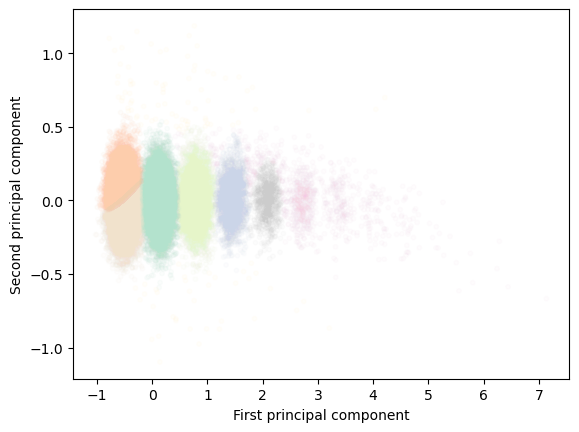

In [25]:
X_pca = reduction(X,PCA,n_components=2)
clustering(X_pca,BayesianGaussianMixture,reg_covar=1e-05,n_components=8, covariance_type='full', random_state=42)

### Kernel 

#### Polynomial

File name :  KernelPCA_dict_items([('n_components', 2), ('kernel', 'poly')])


c:\Users\dalbe\anaconda3\envs\ML\lib\site-packages\sklearn\mixture\_base.py:274: ConvergenceWarning: Initialization 1 did not converge. Try different init parameters, or increase max_iter, tol or check for degenerate data.
  warnings.warn(


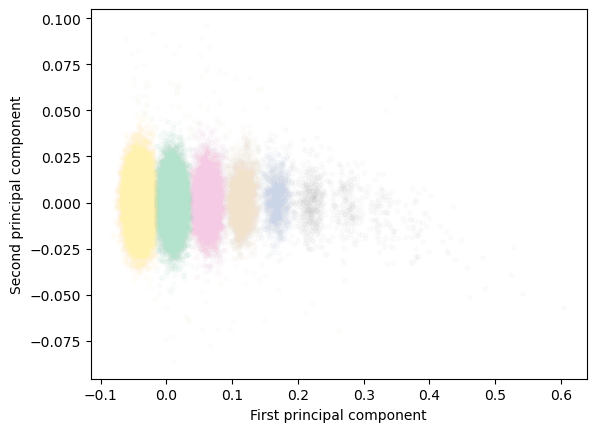

In [26]:
X_kernel_poly = reduction(X,KernelPCA,n_components=2,kernel="poly")
clustering(X_kernel_poly,BayesianGaussianMixture,reg_covar=1e-05,n_components=8, covariance_type='full', random_state=42)

#### Radial basis function (RBF)

File name :  KernelPCA_dict_items([('n_components', 2), ('kernel', 'rbf'), ('gamma', 0.02)])


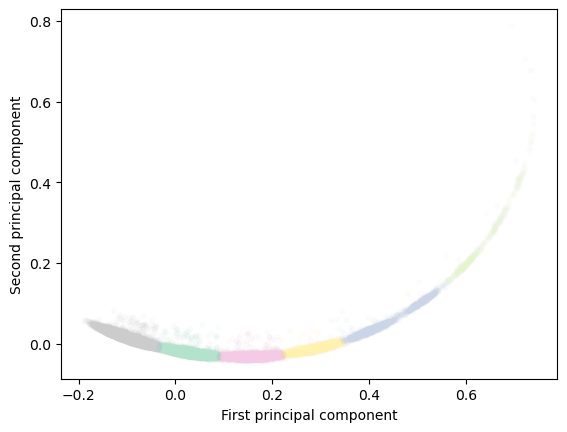

In [27]:
X_kernel_rbf = reduction(X,KernelPCA,n_components=2,kernel="rbf",gamma=0.02)
clustering(X_kernel_rbf,BayesianGaussianMixture,reg_covar=1e-04,n_components=8, covariance_type='full', random_state=42)

#### Sigmoid

File name :  KernelPCA_dict_items([('n_components', 2), ('kernel', 'sigmoid'), ('gamma', 0.02)])


c:\Users\dalbe\anaconda3\envs\ML\lib\site-packages\sklearn\mixture\_base.py:274: ConvergenceWarning: Initialization 1 did not converge. Try different init parameters, or increase max_iter, tol or check for degenerate data.
  warnings.warn(


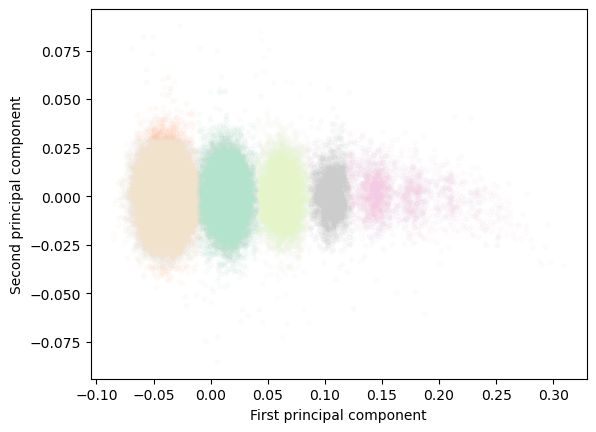

In [28]:
X_kernel_sigmoid = reduction(X,KernelPCA,n_components=2,kernel="sigmoid",gamma=0.02)
clustering(X_kernel_sigmoid,BayesianGaussianMixture,reg_covar=1e-05,n_components=6, covariance_type='full', random_state=42)

#### Cosine

File name :  KernelPCA_dict_items([('n_components', 2), ('kernel', 'cosine'), ('gamma', 0.02)])


c:\Users\dalbe\anaconda3\envs\ML\lib\site-packages\sklearn\mixture\_base.py:274: ConvergenceWarning: Initialization 1 did not converge. Try different init parameters, or increase max_iter, tol or check for degenerate data.
  warnings.warn(


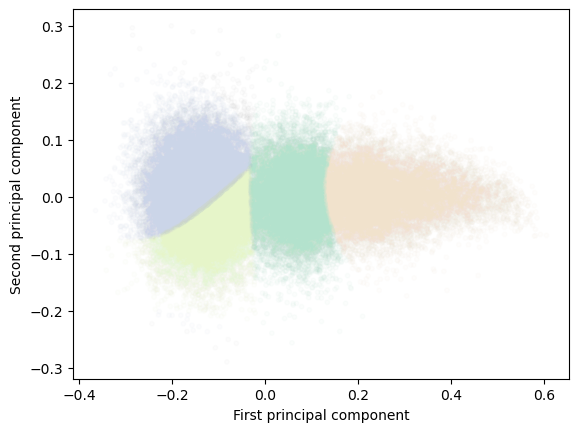

In [29]:
X_kernel_cosine = reduction(X,KernelPCA,n_components=2,kernel="cosine",gamma=0.02)
clustering(X_kernel_cosine,BayesianGaussianMixture,reg_covar=1e-04,n_components=5, covariance_type='full', random_state=42)

### t-distributed Stochastic Neighbor Embedding (t-SNE)



File name :  TSNE_dict_items([('random_state', 42), ('n_components', 2), ('init', 'random')])


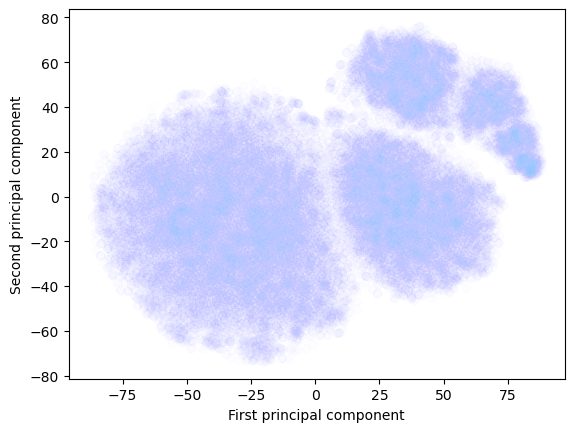

In [30]:
X_tsne = reduction(X,TSNE,random_state=42,n_components=2,init="random", plot=True)
#clustering(X_tsne,DBSCAN,eps=2.1)
#clustering(X_tsne,AffinityPropagation)

### Non-Negative Matrix Factorization (NMF)

File name :  NMF_dict_items([('n_components', 2), ('alpha_W', 0.1), ('random_state', 42)])


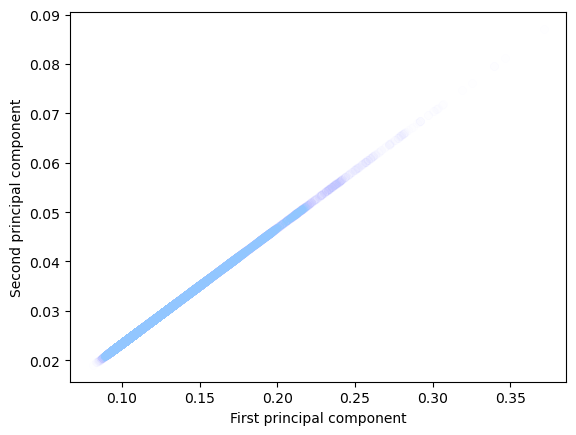

In [31]:
X_NMF = reduction(X,NMF,n_components=2,alpha_W=0.1,random_state=42, plot=True)
#clustering(X_NMF,BayesianGaussianMixture,reg_covar=1e-06,n_components=4, covariance_type='full', random_state=42)

### Isomap

File name :  Isomap_dict_items([('n_neighbors', 20), ('n_components', 2), ('eigen_solver', 'arpack')])


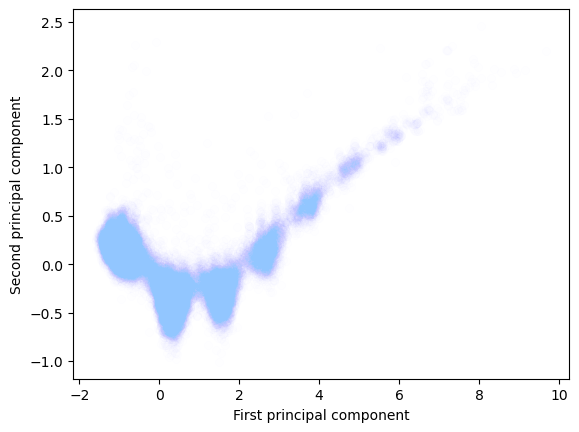

In [32]:
X_Isomap = reduction(X,Isomap, plot=True,n_neighbors=20, n_components=2, eigen_solver="arpack")
#clustering(X_Isomap,BayesianGaussianMixture,reg_covar=1e-02,n_components=7, covariance_type='full', random_state=42)

### Multidimensional scaling

File name :  MDS_dict_items([('n_components', 2), ('max_iter', 10)])


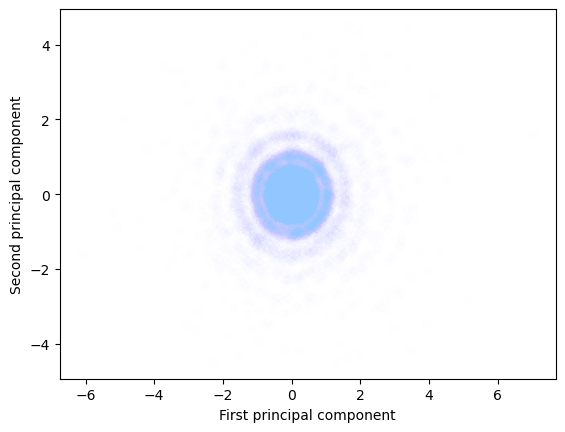

In [33]:
X_MDS = reduction(X,MDS,plot=True,n_components=2,max_iter=10)
#clustering(X_MDS,SpectralClustering,n_clusters=6)

### Locally Linear Embedding (LLE)

File name :  LocallyLinearEmbedding_dict_items([('n_components', 2)])


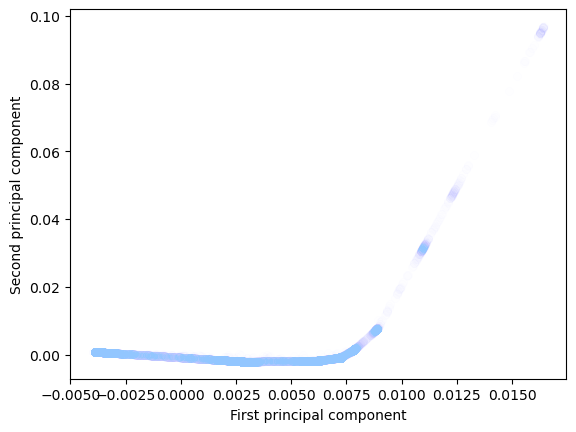

In [34]:
X_LLE = reduction(X,LocallyLinearEmbedding, plot=True,n_components=2)
#lustering(X_LLE,BayesianGaussianMixture,reg_covar=1e-06,n_components=7, covariance_type='full', random_state=42)

### Canonical Correlation Analysis (CCA)

In [35]:
#X_CCA = reduction(X,CCA,n_components=2)

### Custom autoencoder

In [36]:
def open_object(file_name):
        """
        # open_object

        open_object(file_name)

        Open a file using the Pickle library. 
        Is used in this context for files containing dictionaries.

        Parameters
        ----------
        - file_name : str
                - Name of the file to open.

        Returns
        -------
        None
        """
        try:
            with open(file_name, 'rb') as f:
                dictionary = pickle.load(f)
        except Exception as ex:
            print("Error when loading file : ", ex)

        return dictionary

Text(0.5, 0, 'Feature')

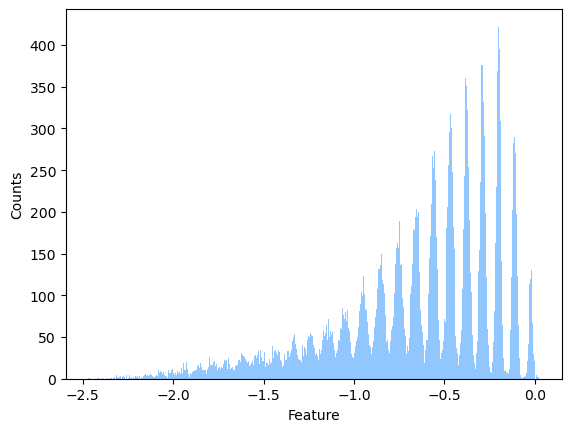

In [37]:
date_time = "run-2023-07-17-15-15/fold 0"
path_save = f"Autoencoder Log/{date_time}/"

X_autoencoder = open_object(f"{path_save}/results.bin")['encode0']

x = plt.hist(X_autoencoder, bins=500)
plt.ylabel("Counts")
plt.xlabel("Feature")
#plt.savefig('demo.png', transparent=True)
#clustering(X_autoencoder,DBSCAN, eps=0.0201,min_samples = 30)

In [39]:
def silhouette_kmean(X, max_cluster):

        X = np.array(X).reshape(-1,1)
        scores = []

        for cluster_number in tqdm(range(2,max_cluster+1) , desc="Clusters") :
            clusters = KMeans(n_clusters=cluster_number , n_init="auto").fit_predict(X[::10])
            scores.append(silhouette_score(X[::10], clusters))

        optimal_cluster = np.argmax(scores) + 1

        labels = KMeans(n_clusters=optimal_cluster, n_init="auto").fit(X).labels_

        out = []
        for label in np.unique(labels):
            out.append(X[labels == label])

        return scores, out, optimal_cluster

Clusters:   0%|          | 0/39 [00:00<?, ?it/s]

c:\Users\dalbe\anaconda3\envs\ML\lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=12.
  warnings.warn(
c:\Users\dalbe\anaconda3\envs\ML\lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=12.
  warnings.warn(
c:\Users\dalbe\anaconda3\envs\ML\lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=12.
  warnings.warn(
c:\Users\dalbe\anaconda3\envs\ML\lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is kn

Optimal number : 20


Text(0.5, 0, 'Number of cluster')

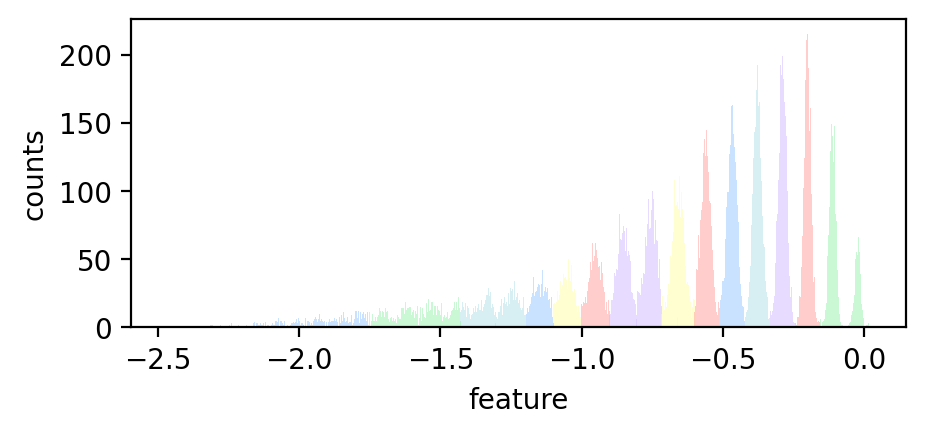

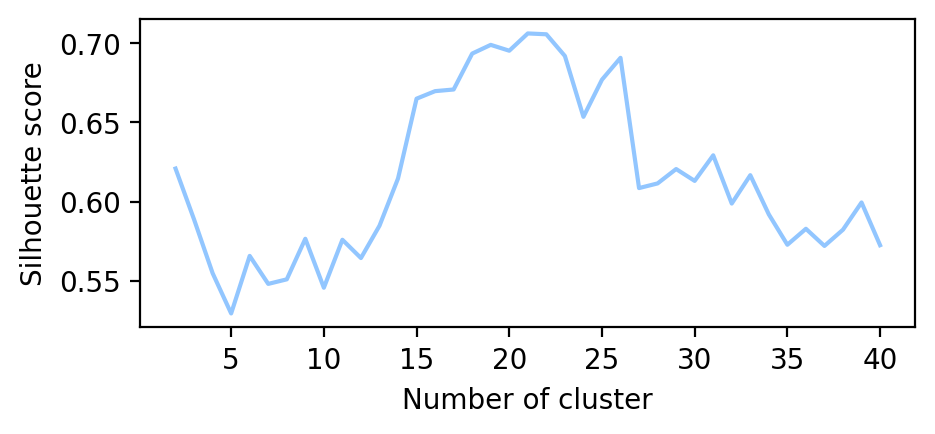

In [40]:
plt.figure(figsize=(5,2),dpi=200)

scores, X, optimal_cluster = silhouette_kmean(X_autoencoder, 40)
print(f"Optimal number : {optimal_cluster}")

bins = np.linspace(min(X_autoencoder), max(X_autoencoder), 1000)

for index, cluster in enumerate(X):
    plt.hist(cluster , bins, alpha = 0.5)

plt.xlabel("feature")
plt.ylabel("counts")

plt.figure(figsize=(5,2),dpi=200)

plt.plot(range(2, len(scores)+2), scores)
plt.ylabel("Silhouette score")
plt.xlabel("Number of cluster")